# MF-SHRED for the MSFR: from an ODE model to the MP PDE

This notebook applies **multi-fidelity SHRED (MF-SHRED)** to the parametric MSFR unprotected loss-of-flow (ULOFF) dataset (D2). A zero-dimensional circulating-fuel DDE supplies **low-fidelity (LF)** scalar trajectories; OpenFOAM multi-physics simulations supply the **multi-physics (MP)** spatial reference. MF-SHRED maps a short history of LF measurements to POD coefficients of the MP field, which are decoded back to the mesh for reconstruction and comparison.

**Workflow**

1. Load paired MP snapshots and LF trajectories from `NuSHRED_Datasets/D2/`.
2. Extract random subsets of LF variables as input sensors (ensemble of configurations).
3. Train one MF-SHRED network per sensor configuration to predict scaled POD coefficients.
4. Evaluate coefficient-space error, decode to physical space, and quantify reconstruction error.
5. Compare lumped in-core averages and spatial contours across **MP**, **MF-SHRED**, and **LF**.

**Dependencies:** `numpy`, `matplotlib`, `seaborn`, `scikit-learn`, `torch`, and the shared `shred` package. LF data are generated in `01_LF_vs_HF_comparison.ipynb`. Contour plotting reuses utilities from `Code/P2/`.

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import seaborn as sns

import sys
sys.path.append('../../P2/')

path_snaps = '../../../NuSHRED_Datasets/D2/'
idx_params, params, var_names, is_vector, fom_times, rescaling_snaps, Nmodes = pickle.load(open(path_snaps+'msfr_p.uloff', 'rb'))

_lf_data = pickle.load(open(path_snaps+'dataset_lf_uloff.pkl', 'rb'))
lf_timegrid = np.array(_lf_data['time_grid'])

lf_snaps = np.zeros((len(_lf_data['outputs']), len(fom_times), _lf_data['outputs'][0].shape[1]))
for ii in range(len(_lf_data['outputs'])):
    for _jj in range(_lf_data['outputs'][ii].shape[1]):
        lf_snaps[ii, :, _jj] = np.interp(fom_times, lf_timegrid, _lf_data['outputs'][ii][:, _jj])

Nh_lf = lf_snaps.shape[-1]
Nt = len(fom_times)
Nmodes = [10] * len(var_names)

lf_var_names = _lf_data['var_names']
hf_to_lf_idx = {name: lf_var_names.index(name) for name in lf_var_names if name in var_names}

_nodes = pickle.load(open(path_snaps + 'domain.pkl', 'rb'))

def _is_out_core(node):
    return ((node[1] <= -1.0125 or node[1] >= 1.0125) or node[0] >= 2.05)

in_core_idx = np.where([not _is_out_core(node) for node in _nodes])[0]
del _nodes

## Load dataset

We load the pre-compressed MSFR-ULOFF metadata bundle `msfr_p.uloff` and the LF dataset `dataset_lf_uloff.pkl` (built in `01_LF_vs_HF_comparison.ipynb`).

- **MP snapshots** — POD-compressed OpenFOAM fields indexed by train/valid/test parameter splits; temporal coefficients, per-field scalers, and mode counts are provided.
- **LF trajectories** — lumped scalars (`q`, `prec1`–`prec8`, `T`) from the 0D circulating-fuel DDE, interpolated onto the MP time grid.
- **Mesh** — node coordinates in `domain.pkl`; an in-core mask excludes out-of-core nodes when computing spatial averages for LF comparison.

The mapping `hf_to_lf_idx` links HF field names to LF column indices wherever a direct counterpart exists.

## Extract LF sensor measurements

Unlike baseline SHRED (sparse MP sensors), MF-SHRED uses **LF trajectories** as input. For each of `n_configurations` random draws, we select `num_lf_sensors` LF variables (columns of `lf_snaps`) and record their time histories for every parameter case.

Each configuration defines a distinct input channel; measurements are scaled to $[0,1]$ with a `MinMaxScaler` fitted on the training set. The ensemble of configurations is aggregated later when reporting mean predictions and uncertainty.

In [2]:
num_lf_sensors = 3
n_configurations = 10

np.random.seed(8)
idx_lf_sensor_locations = np.zeros((num_lf_sensors, n_configurations), dtype=int)

for kk in range(n_configurations):
    idx_lf_sensor_locations[:, kk] = np.asarray(
        np.random.choice(Nh_lf, size=num_lf_sensors, replace=False), dtype=int
    )

lf_measurements = {
    key: np.zeros((len(idx_params[key]), Nt, num_lf_sensors)) for key in idx_params
}

for key in idx_params:
    for kk in range(n_configurations):
        lf_measurements[key] = lf_snaps[idx_params[key]][:, :, idx_lf_sensor_locations[:, kk]]

from sklearn.preprocessing import MinMaxScaler
lf_meas_scaler = [MinMaxScaler() for kk in range(n_configurations)]
for kk in range(n_configurations):
    lf_meas_scaler[kk].fit(lf_measurements['train'].reshape(-1, num_lf_sensors))

scaled_lf_measurements = [{
    key: lf_meas_scaler[kk].transform(lf_measurements[key].reshape(-1, num_lf_sensors)).reshape(lf_measurements[key].shape)
    for key in idx_params
} for kk in range(n_configurations)]

## Prepare data for MF-SHRED

The MP fields are already represented by their POD coefficients (Paper 2 SVD pipeline). MF-SHRED is trained to predict the **scaled** coefficient vector from lagged LF sensor windows.

### Load POD coefficients

Per-field temporal POD coefficients are loaded from `CompressedDataset/v_POD_all_fields.svd` and concatenated into a single latent vector of dimension $R = \sum_i N_{\mathrm{modes},i}$. A global `MinMaxScaler` (fitted on training coefficients) maps each mode to $[0,1]$ before training.

In [3]:
svd_coeff_per_field = pickle.load(open(f'{path_snaps}CompressedDataset/v_POD_all_fields.svd', 'rb'))

pod_coeffs = {
    key: np.zeros((len(idx_params[key]), Nt, sum(Nmodes))) for key in idx_params
}

for key in idx_params:
    for field_i in range(len(var_names)):
        pod_coeffs[key][:, :, sum(Nmodes[:field_i]):sum(Nmodes[:field_i+1])] = svd_coeff_per_field[var_names[field_i]][idx_params[key], :, :Nmodes[field_i]]

pod_scaler = MinMaxScaler()
pod_scaler.fit(pod_coeffs['train'].reshape(-1, sum(Nmodes)))

rescaled_pod_coeffs = {
    key: pod_scaler.transform(pod_coeffs[key].reshape(-1, sum(Nmodes))).reshape(pod_coeffs[key].shape)
    for key in idx_params
}


### Build lagged datasets

We construct lagged input windows (`lags = 40`) from the scaled LF sensor trajectories and pair them with the scaled POD coefficient vector at the same time index. Separate `TimeSeriesDataset` objects are created for each sensor configuration.

In [4]:
import sys
sys.path.append('../../../')

from shred.processdata import Padding, TimeSeriesDataset
import torch

# GPU
device = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')

lags = 40

# Input Data
train_data_in = [Padding(torch.from_numpy(scaled_lf_measurements[kk]['train']), lags).to(device) for kk in range(n_configurations)]
valid_data_in = [Padding(torch.from_numpy(scaled_lf_measurements[kk]['valid']), lags).to(device) for kk in range(n_configurations)]
test_data_in  = [Padding(torch.from_numpy(scaled_lf_measurements[kk]['test']), lags).to(device)  for kk in range(n_configurations)]

# Output Data
train_data_out = Padding(torch.from_numpy(rescaled_pod_coeffs['train']), 1).squeeze(1).to(device)
valid_data_out = Padding(torch.from_numpy(rescaled_pod_coeffs['valid']), 1).squeeze(1).to(device)
test_data_out  = Padding(torch.from_numpy(rescaled_pod_coeffs['test']), 1).squeeze(1).to(device)

# Create Dataset for SHRED training
mf_train_dataset = [TimeSeriesDataset(train_data_in[kk], train_data_out) for kk in range(n_configurations)]
mf_valid_dataset = [TimeSeriesDataset(valid_data_in[kk], valid_data_out) for kk in range(n_configurations)]
mf_test_dataset  = [TimeSeriesDataset(test_data_in[kk],  test_data_out)  for kk in range(n_configurations)]

### MF-SHRED training

One SHRED network is trained per LF sensor configuration. Each model maps $(\text{lags} \times n_{\mathrm{LF\text{-}sensors}})$ inputs to the $R$-dimensional scaled POD coefficient vector. Training uses early stopping on the validation set; trained weights are saved under `Results/SHRED/`.

Set `train_net = True` to retrain from scratch, or `False` to load existing checkpoints.

In [5]:
from shred.models import SHRED, fit
from time import perf_counter
import os

mfshred = list()
mf_training_time = []

train_net = False
path_shred = 'Results/SHRED/'
os.makedirs(path_shred, exist_ok=True)
computational_times = dict()

for kk in range(n_configurations):
    
    mfshred.append(SHRED( num_lf_sensors, sum(Nmodes), 
                        hidden_size = 64, hidden_layers = 2, decoder_sizes = [350, 400], dropout = 0.1).to(device))

    if train_net:
        _start_time = perf_counter()
        print('Training SHRED - configuration '+str(kk+1)+'/'+str(n_configurations))

        fitting_errors = fit(   mfshred[kk], mf_train_dataset[kk], mf_valid_dataset[kk], batch_size = 64, epochs = 500, lr = 1e-3, verbose = True, patience = 30)

        mfshred[kk].freeze()

        torch.save(mfshred[kk].state_dict(), path_shred+'MFSHRED_trained_config'+str(kk)+'_measuring_'+str(num_lf_sensors)+'.shred')

        _end_time = perf_counter()
        mf_training_time.append(_end_time - _start_time)
    else:
        mfshred[kk].load_state_dict(torch.load(path_shred+'MFSHRED_trained_config'+str(kk)+'_measuring_'+str(num_lf_sensors)+'.shred', map_location=device))
        mfshred[kk].freeze()

if train_net:
    np.save(path_shred+'mf_training_time.npy', mf_training_time)
else:
    mf_training_time = np.load(path_shred+'mf_training_time.npy')

computational_times['MF-SHRED'] = {
    'Training': mf_training_time
}

### Test-set evaluation in coefficient space

MF-SHRED predictions from all sensor configurations are stacked and aggregated (mean, standard error, covariance). We report the mean relative error (MRE) on the **scaled** POD coefficients for the ensemble mean and its propagated uncertainty.

In [6]:
_start_time = perf_counter()

mf_pred_pod_hat = torch.stack([mfshred[kk](test_data_in[kk]) for kk in range(n_configurations)], dim=0)

mf_pred_pod = {
    'mean': mf_pred_pod_hat.mean(axis=0),
    'std':  mf_pred_pod_hat.std(axis=0) / np.sqrt(n_configurations),
    'cov': torch.stack([torch.cov(mf_pred_pod_hat[:, i, :sum(Nmodes)].T) for i in range(mf_pred_pod_hat.shape[1])]) / n_configurations 
}
computational_times['MF-SHRED']['Prediction'] = perf_counter() - _start_time

# The test data are independent on the configurations of the sensors
from shred.processdata import num2p, mre
print("Mean relative SHRED prediction error on POD coeffs: %s." % num2p(mre(test_data_out,
                                                                            mf_pred_pod['mean']).detach().item()))
print("Std  relative SHRED prediction error on POD coeffs: %s." % num2p((mf_pred_pod['std'].pow(2).sum(axis = -1).sqrt() / (test_data_out).pow(2).sum(axis = -1).sqrt()).mean().detach().item()))

Mean relative SHRED prediction error on POD coeffs: 2.12%.
Std  relative SHRED prediction error on POD coeffs: 0.44%.


### Per-configuration POD coefficient errors

Mean relative error (MRE) of each MF-SHRED sensor configuration against the test-set ground-truth POD coefficients, compared with the ensemble-mean prediction reported above.

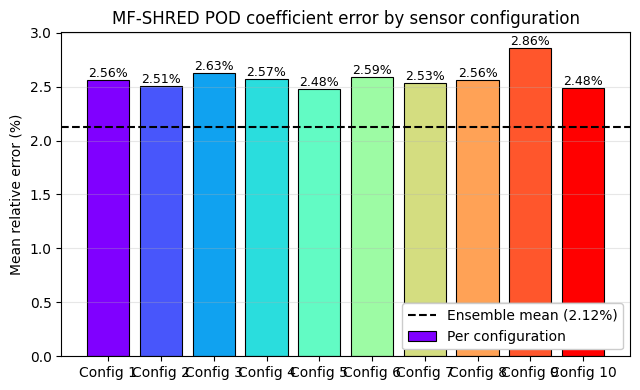

In [7]:
from shred.processdata import num2p, mre

config_mre = np.array([
    mre(test_data_out, mf_pred_pod_hat[kk]).detach().item()
    for kk in range(n_configurations)
])
ensemble_mre = mre(test_data_out, mf_pred_pod['mean']).detach().item()

fig, ax = plt.subplots(figsize=(6.5, 4))
colors = plt.cm.rainbow(np.linspace(0, 1, n_configurations))
x = np.arange(n_configurations)

bars = ax.bar(
    x,
    config_mre * 100,
    color=colors,
    edgecolor='k',
    linewidth=0.8,
    label='Per configuration',
)
ax.axhline(
    ensemble_mre * 100,
    color='k',
    ls='--',
    lw=1.5,
    label=f'Ensemble mean ({num2p(ensemble_mre)})',
)

ax.set_xticks(x)
ax.set_xticklabels([f'Config {kk + 1}' for kk in range(n_configurations)])
ax.set_ylabel('Mean relative error (%)')
ax.set_title('MF-SHRED POD coefficient error by sensor configuration')
ax.bar_label(bars, labels=[f'{v * 100:.2f}%' for v in config_mre], fontsize=9)
ax.legend(loc='lower right', framealpha=1)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Reshape MF-SHRED outputs

The raw network output has shape $(N_p^{\mathrm{test}} \cdot N_t,\, R)$. We reshape it to $(N_p^{\mathrm{test}},\, N_t,\, R)$ so that each test parameter case and time step can be accessed directly, with mode blocks aligned to the `Nmodes` slice indices.

In [8]:
mf_reshaped_test_out = test_data_out.cpu().detach().numpy().reshape(len(idx_params['test']), Nt, sum(Nmodes))

_start_time = perf_counter()
mf_reshaped_POD_pred_out = {
    'mean': mf_pred_pod['mean'].cpu().detach().numpy().reshape(len(idx_params['test']), Nt, sum(Nmodes)),
    'std':  mf_pred_pod['std'].cpu().detach().numpy().reshape(len(idx_params['test']), Nt, sum(Nmodes)),
    'full': mf_pred_pod_hat[:, :, :sum(Nmodes)].cpu().detach().numpy().reshape(n_configurations, len(idx_params['test']), len(fom_times), sum(Nmodes))
}
computational_times['MF-SHRED']['Reshape'] = perf_counter() - _start_time

### Per-mode POD coefficient error

Mean relative error for each scaled POD coefficient, with vertical dashed lines separating field blocks. Error bars reflect uncertainty propagated from the ensemble of LF sensor configurations.


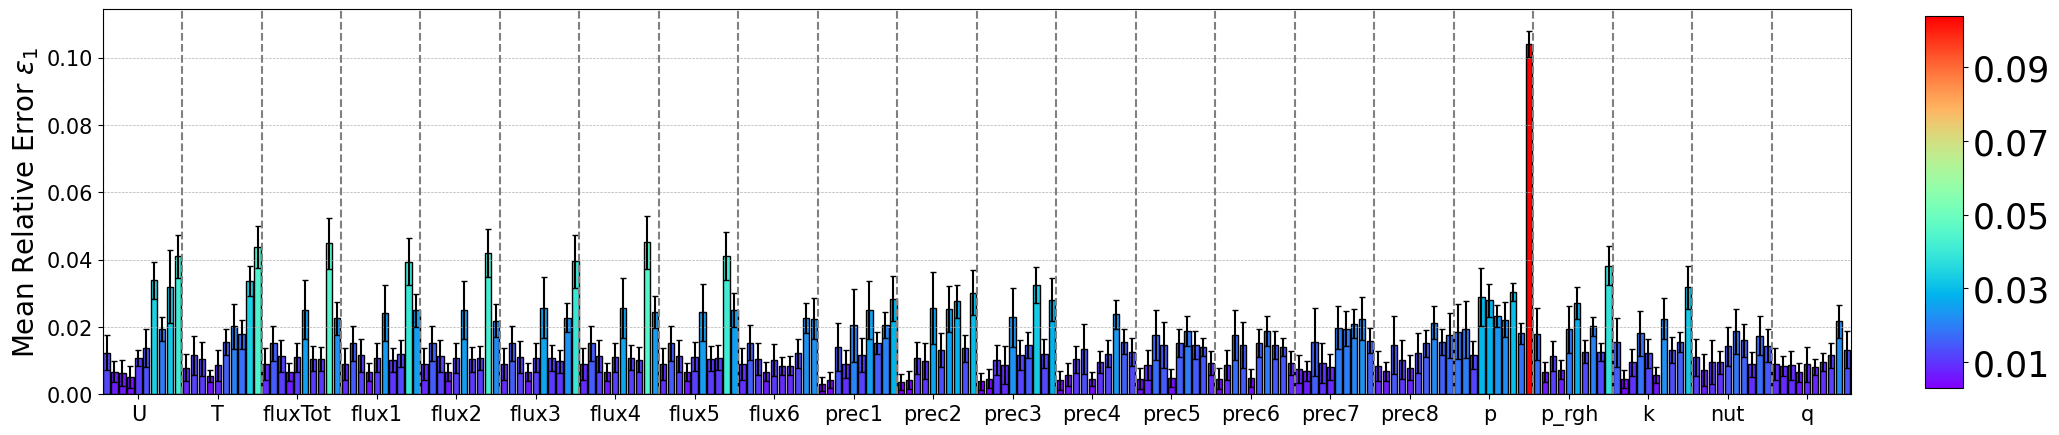

In [9]:
from matplotlib.colors import Normalize

# errors_pod_coeffs already computed
errors_pod_coeffs = [np.mean(np.abs(mf_reshaped_test_out[:, :, pp] - mf_reshaped_POD_pred_out['mean'][:, :, pp]), axis=(0,1)) / np.mean(np.abs(mf_reshaped_test_out[:, :, pp]))
                     for pp in range(mf_reshaped_test_out.shape[2])]
err_std_pod_coeffs = [np.mean(mf_reshaped_POD_pred_out['std'][:, :, pp], axis=(0,1)) / np.mean(np.abs(mf_reshaped_test_out[:, :, pp]))
                     for pp in range(mf_reshaped_test_out.shape[2])]

fig, axs = plt.subplots(1, 1, figsize=(24, 5))

# Normalize error values to [0,1] for colormap mapping
norm = Normalize(vmin=min(errors_pod_coeffs), vmax=max(errors_pod_coeffs))
cmap = cm.rainbow  # choose your favorite colormap here
colors = cmap(norm(errors_pod_coeffs))

# Plot bars with colors
bars = axs.bar(np.arange(sum(Nmodes)), errors_pod_coeffs, 
               yerr = err_std_pod_coeffs, ecolor='k', capsize=2,
               edgecolor='k',
               color=colors)

# Vertical lines for Nmodes grouping
for pp in range(len(Nmodes)):
    axs.axvline(x=np.cumsum(Nmodes)[pp]-Nmodes[0]-0.5, color='gray', linestyle='--')

axs.tick_params(axis='both', which='major', labelsize=15)
axs.set_ylabel(r'Mean Relative Error $\varepsilon_1$', fontsize=20)

# Add x-ticks for modes grouping
xticks = []
xtick_labels = []
for pp in range(len(Nmodes)):
    xticks.append(np.cumsum(Nmodes)[pp]-Nmodes[0]/2-1)
    xtick_labels.append(f'{var_names[pp]}')
axs.set_xticks(xticks)
axs.set_xticklabels(xtick_labels, rotation=0, fontsize=15)

axs.grid(which='both', axis='y', linestyle='--', linewidth=0.5)
axs.set_xlim(-0.5, sum(Nmodes)-0.5)
axs.set_ylim(0, max(errors_pod_coeffs)*1.1)

# Add colorbar for reference
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axs, fraction=0.02, pad=0.04, aspect=10)
cbar.ax.tick_params(labelsize=25)
# cbar.ax.set_ylabel('Error value', fontsize=30)
cbar.ax.set_yticks(np.arange(0.01, 0.11, 0.02))

### LaTeX variable names

Human-readable LaTeX labels for each HF field are defined for consistent figure annotation across POD-coefficient, QoI, and contour plots.

In [10]:
tex_var_names = [r'\mathbf{u}', 'T', '\Phi']
energy_groups = 6
tex_var_names.extend([r'\phi_'+str(g+1) for g in range(energy_groups)])

prec_groups = 8
tex_var_names.extend([r'c_'+str(g+1) for g in range(prec_groups)])

tex_var_names.extend(['p', r'p_{\text{rgh}}', r'\kappa', r'\nu_t', "q'''"])

assert len(tex_var_names) == len(var_names)

### POD coefficient dynamics (single test case)

For one test parameter $\tau^\star$, we overlay the ground-truth scaled POD coefficients with the MF-SHRED ensemble prediction (mean $\pm 1.96\sigma$ across sensor configurations), grouped by field.

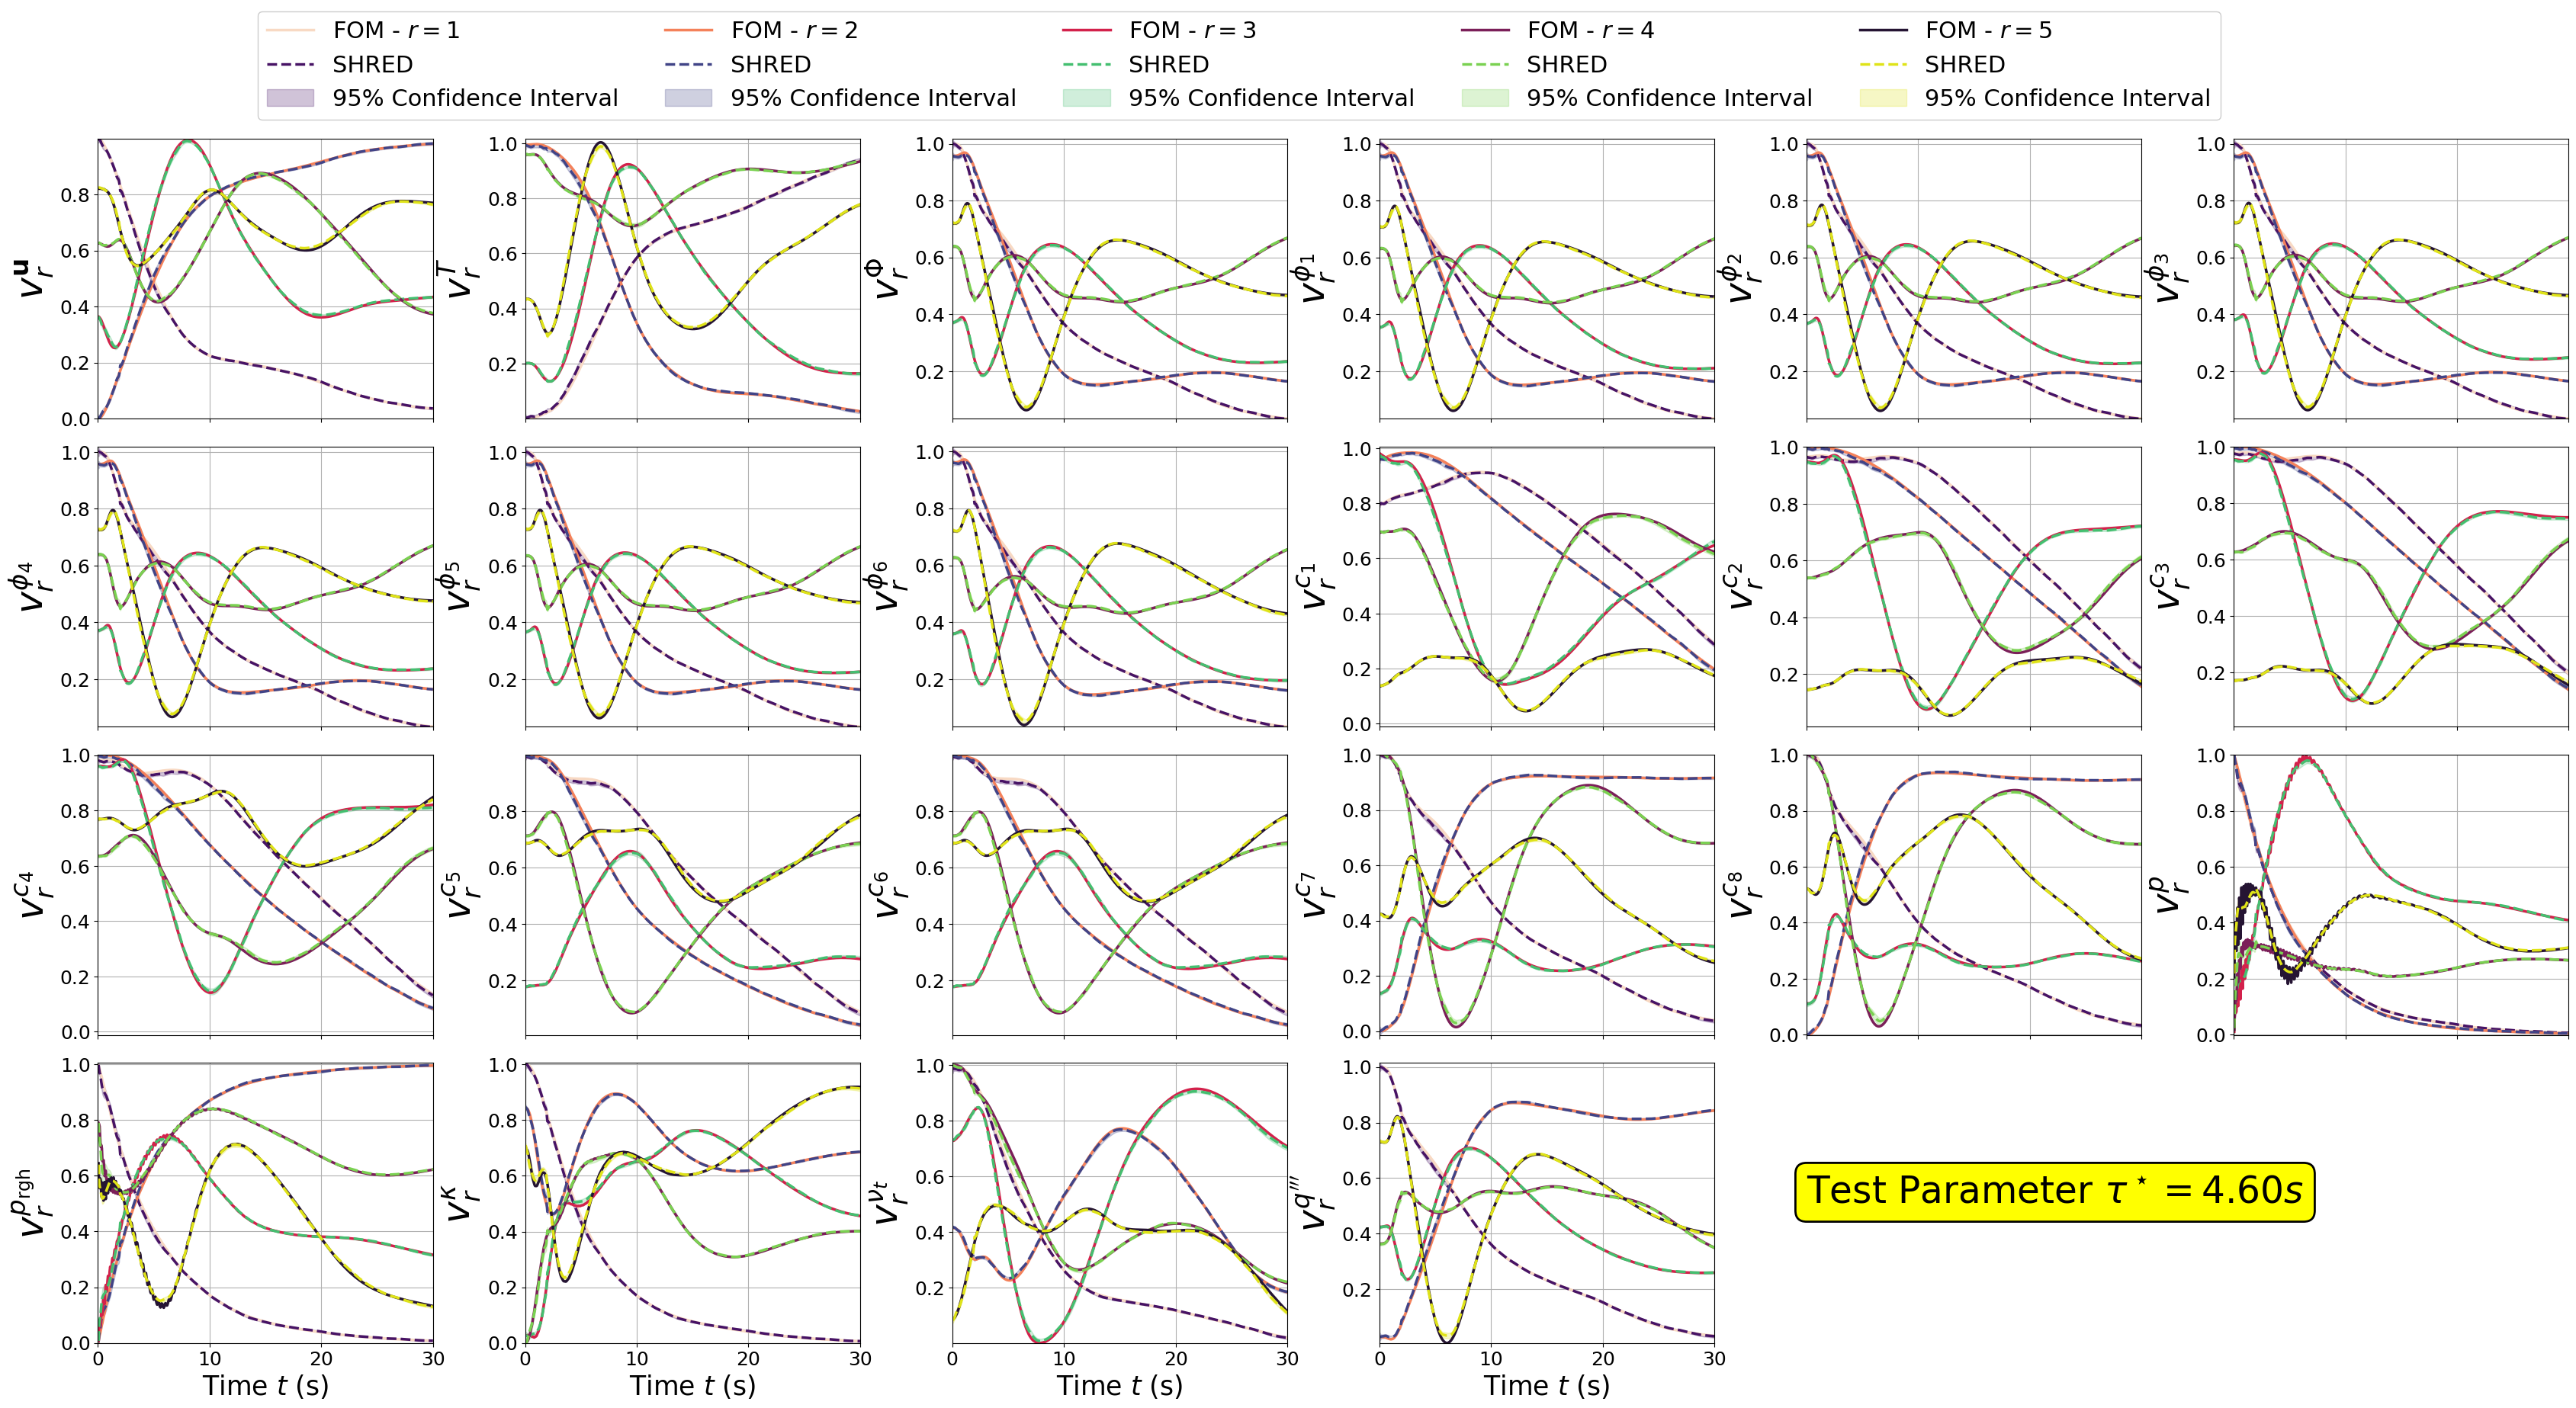

In [11]:
modes_to_plot = 5
param_to_plot = 0

path_test = './Results/'

nrows = 4
ncols = 6
fig, axs = plt.subplots(nrows = nrows, ncols=ncols, sharex=True, figsize=(6 * ncols, 5 * nrows))
axs = axs.flatten()

ls = 2.5

for field_i, field in enumerate(var_names):

    idx_to_plot = np.arange(sum(Nmodes[:field_i]),
                            modes_to_plot + sum(Nmodes[:field_i]),
                            1, 
                            dtype=int)

    # colors = cm.jet([0.05, 0.2, 0.7, 0.8, 0.95])
    # colors_gt = cm.plasma(np.linspace(0.1,0.95,len(idx_to_plot)))

    colors = cm.viridis([0.05, 0.2, 0.7, 0.8, 0.95])
    colors_gt = sns.color_palette("rocket", as_cmap=True)(np.linspace(0.1,0.95,len(idx_to_plot)))
    for ii, idx in enumerate(idx_to_plot):
        axs[field_i].plot(fom_times, mf_reshaped_test_out[param_to_plot,:,idx],
                          '-', linewidth=ls, c=colors_gt[-1-ii], label=r'FOM - $r='+str(ii+1)+'$')
        axs[field_i].plot(fom_times, mf_reshaped_POD_pred_out['mean'][param_to_plot,:,idx],
                          '--', c=colors[ii], label=r'SHRED', linewidth=ls)
        axs[field_i].fill_between(fom_times,
                                    y1 = mf_reshaped_POD_pred_out['mean'][param_to_plot,:,idx] - 1.96 * mf_reshaped_POD_pred_out['std'][param_to_plot,:,idx],
                                    y2 = mf_reshaped_POD_pred_out['mean'][param_to_plot,:,idx] + 1.96 * mf_reshaped_POD_pred_out['std'][param_to_plot,:,idx],
                                    color=colors[ii], alpha=0.25, label=r'95% Confidence Interval')

    axs[field_i].set_ylabel(r'$v_r^{'+tex_var_names[field_i]+r'}$', fontsize=35)
    axs[field_i].grid()

    axs[field_i].set_ylim(mf_reshaped_test_out[:,:,idx_to_plot].min(), 
                          mf_reshaped_test_out[:,:,idx_to_plot].max())
    axs[field_i].set_xlim(0, fom_times[-1])
    axs[field_i].tick_params(axis='both', labelsize=18)
    
    # axs[field_i].set_xticks((np.array([0.5, 1.5, 2.5]) + new_t[-1] * np.arange(len(param_to_plot))[:, None]).flatten())
    # axs[field_i].set_xticklabels(np.hstack([[0.5, 1.5, 2.5] for _ in range(len(param_to_plot))]))

for field_i in range(len(var_names), nrows * ncols):
    axs[field_i].axis('off')

Line, Label = axs[0].get_legend_handles_labels()
fig.legend(Line, Label, fontsize=22, ncols=5, framealpha=1, loc=(0.1, 0.915))

axs = axs.reshape(nrows, ncols)
axs[-1, -2].annotate(   r'Test Parameter $\tau^\star = {:.2f} s$'.format(params[idx_params['test'][param_to_plot],0]), 
                        xy=(0., .5), xycoords='axes fraction', fontsize=35, color='black',
                        bbox=dict(boxstyle="round,pad=0.3", edgecolor='black', facecolor='yellow', lw=2))

[ax.set_xlabel(r'Time $t$ (s)', fontsize=25) for ax in axs[-1]]

fig.subplots_adjust(left=0, hspace=0.1, top = 0.9, wspace=0.275)
fig.savefig(path_test+'SHRED_dynamics_uq.pdf', format='pdf', dpi=250, bbox_inches='tight')

### POD coefficient dynamics (all test cases)

The same comparison is repeated for every test value of $\tau^\star$ on a subset of fields, highlighting how MF-SHRED tracks the latent dynamics across the ULOFF transient.

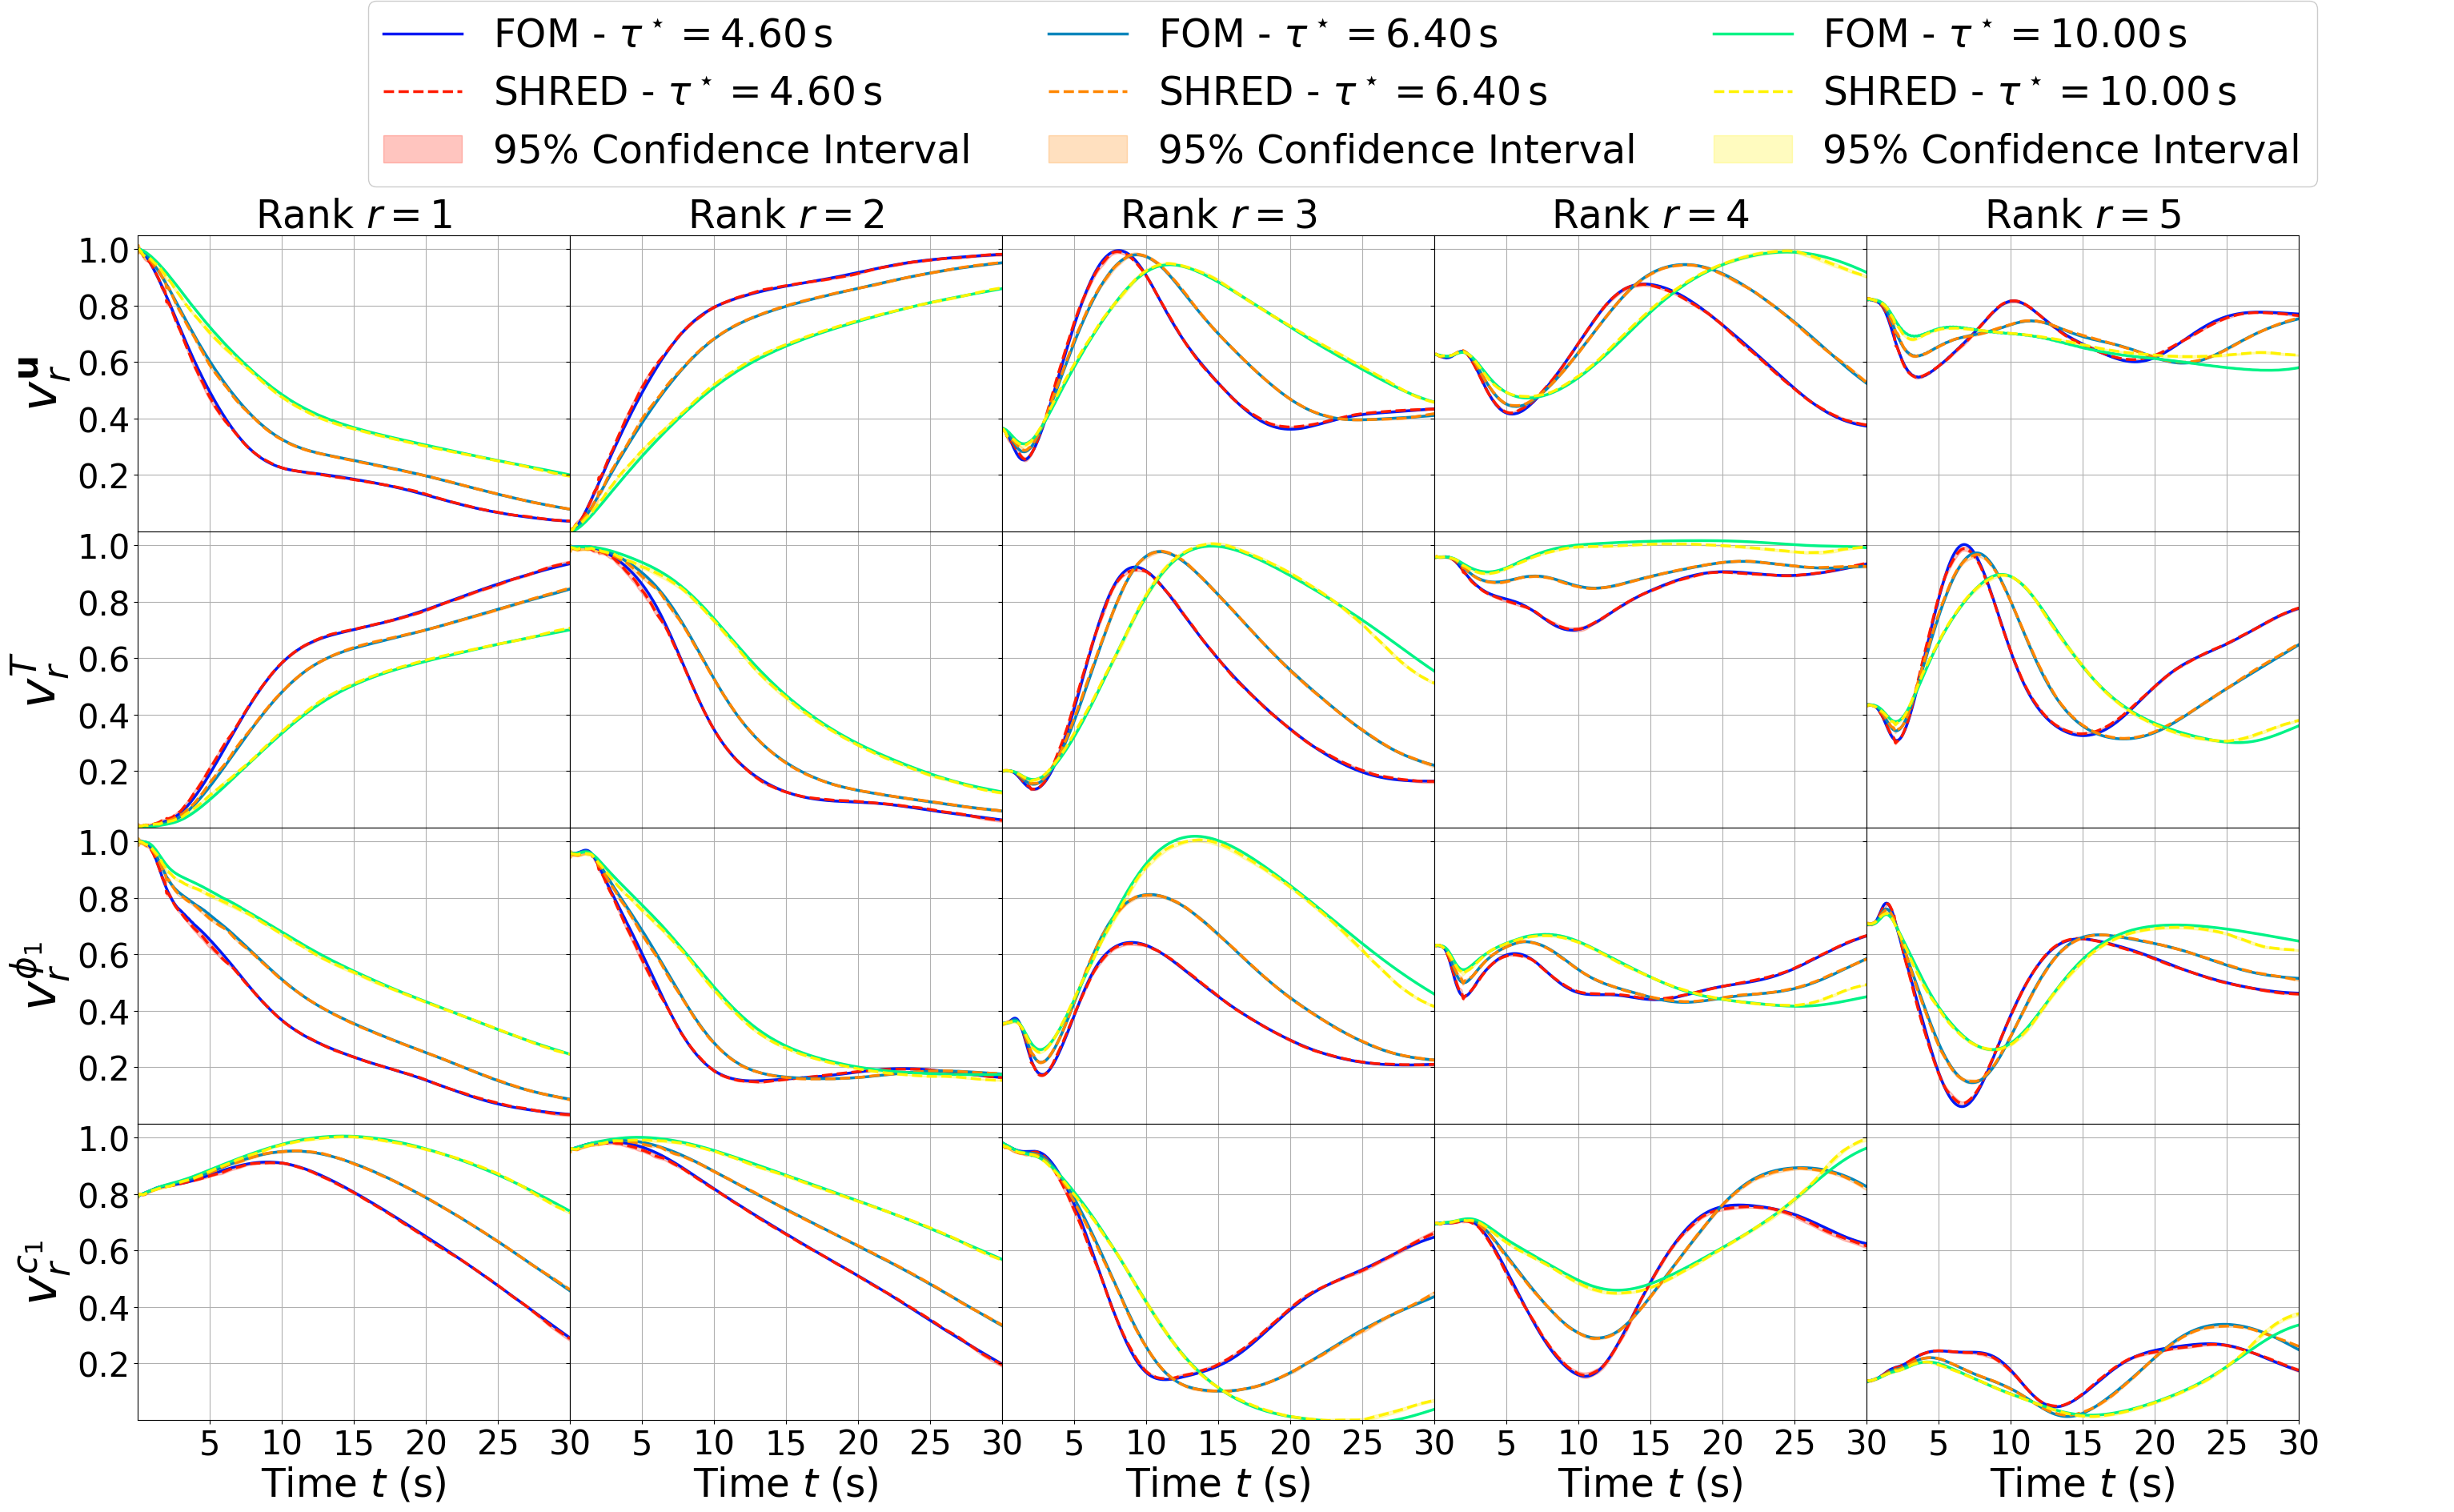

In [12]:
fields_idx_to_plot = [0,1,3,9]
modes_to_plot = 5

nrows = len(fields_idx_to_plot)
ncols = modes_to_plot

fig, axs = plt.subplots(nrows = nrows, ncols=ncols, sharex=True, sharey=True, figsize=(6 * ncols, 5 * nrows))

ls = 2.5

for ii, field_i in enumerate(fields_idx_to_plot):
    idx_to_plot = np.arange(sum(Nmodes[:field_i]),
                            modes_to_plot + sum(Nmodes[:field_i]),
                            1, 
                            dtype=int)

    colors = cm.autumn(np.linspace(0.1,0.95,len(idx_params['test'])))
    colors_gt = cm.winter(np.linspace(0.1,0.95,len(idx_params['test'])))

    for jj, idx in enumerate(idx_to_plot):
        for param_to_plot in range(len(idx_params['test'])):
            axs[ii, jj].plot(fom_times, mf_reshaped_test_out[param_to_plot,:,idx],
                            '-', linewidth=ls, c=colors_gt[param_to_plot], label=r'FOM - $\tau^\star = {:.2f}\, \text{{s}}'.format(params[idx_params['test'][param_to_plot],0])+'$')
            axs[ii, jj].plot(fom_times, mf_reshaped_POD_pred_out['mean'][param_to_plot,:,idx],
                                '--', c=colors[param_to_plot], label=r'SHRED - $\tau^\star = {:.2f}\, \text{{s}}'.format(params[idx_params['test'][param_to_plot],0])+'$', linewidth=ls)
            axs[ii, jj].fill_between(fom_times,
                                    y1 = mf_reshaped_POD_pred_out['mean'][param_to_plot,:,idx] - 1.96 * mf_reshaped_POD_pred_out['std'][param_to_plot,:,idx],
                                    y2 = mf_reshaped_POD_pred_out['mean'][param_to_plot,:,idx] + 1.96 * mf_reshaped_POD_pred_out['std'][param_to_plot,:,idx],
                                    color=colors[param_to_plot], alpha=0.25, label=r'95% Confidence Interval')
        axs[ii,jj].grid()
        axs[ii,jj].tick_params(axis='both', labelsize=30)
        axs[ii, jj].set_xlim(0, fom_times[-1])
        axs[ii, jj].set_ylim(0, 1.05)
        axs[ii, jj].set_xticks([5, 10, 15, 20, 25, 30])
        axs[ii, jj].set_yticks(np.arange(0.2, 1.01, 0.2))
    
[axs[0, jj].set_title(r'Rank $r='+str(jj+1)+'$', fontsize=35) for jj in range(ncols)]
[axs[ii, 0].set_ylabel(r'$v_r^{'+tex_var_names[fields_idx_to_plot[ii]]+r'}$', fontsize=45) for ii in range(nrows)]
[axs[-1, jj].set_xlabel(r'Time $t$ (s)', fontsize=35) for jj in range(ncols)]

Line, Label = axs[0,0].get_legend_handles_labels()
fig.legend(Line, Label, fontsize=35, ncols=3, framealpha=1, loc=(0.15, 0.8765))

fig.subplots_adjust(left=0, hspace=0.0, top = 0.85, wspace=0.)
fig.savefig(path_test+'SHRED_dynamics_test_parameters.pdf', format='pdf', dpi=10, bbox_inches='tight')
# fig.savefig(path_test+'SHRED_dynamics_test_parameters.png', format='png', dpi=150, bbox_inches='tight')

### Decode to the physical mesh

Predicted POD coefficients are inverse-scaled and projected onto the truncated spatial basis to recover full MP fields. The relative reconstruction error is

$$\varepsilon_2(t) = \frac{\|\mathbf{u}_{\mathrm{MP}}(t) - \mathbf{u}_{\mathrm{SHRED}}(t)\|_2}{\|\mathbf{u}_{\mathrm{MP}}(t)\|_2},$$

computed at each time step and averaged over test parameter cases. Uncertainty across sensor configurations is propagated in the same norm.

In [13]:
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
from IPython.display import clear_output as clc

ave_rel_errors = {
    'mean': np.zeros((len(var_names), len(idx_params['test']), len(fom_times))),
    'std' : np.zeros((len(var_names), len(idx_params['test']), len(fom_times)))
}

for field_i in range(len(var_names)):
    field = var_names[field_i]
    idx_to_rec = np.arange(sum(Nmodes[:field_i]),  sum(Nmodes[:field_i+1]),  1, dtype=int)

    # Load compressed dataset
    u_data  = pickle.load(open(path_snaps + f'CompressedDataset/pod_basis_{field}.svd', 'rb'))
    s_data  = pickle.load(open(path_snaps + f'CompressedDataset/sing_vals_{field}.svd', 'rb'))
    vh_data = pickle.load(open(path_snaps + f'CompressedDataset/v_POD_all_fields.svd', 'rb'))[field]

    for param_to_recon in tqdm(range(len(idx_params['test'])), 'Computing error for '+field):
        fom = u_data @ s_data @ vh_data[idx_params['test'][param_to_recon]].T

        u_svd = u_data[:, :Nmodes[field_i]]
        s_svd = s_data[:Nmodes[field_i], :Nmodes[field_i]]

        # Scale the components of the v-coefficients to the original range
        # _tmp_mean_v = vpod_scaler.inverse_transform(reshaped_POD_test_out['mean'][:,:,:-1].reshape(-1, sum(Nmodes))).reshape(reshaped_POD_test_out['mean'][:,:,:-1].shape)
        # _tmp_std_v  = vpod_scaler.inverse_transform(reshaped_POD_test_out['std'][:,:,:-1].reshape( -1, sum(Nmodes))).reshape(reshaped_POD_test_out['std'][:,:,:-1].shape) - vpod_scaler.data_min_
        _tmp_v = {
            'mean': pod_scaler.inverse_transform(mf_reshaped_POD_pred_out['mean'].reshape(-1, sum(Nmodes))).reshape(mf_reshaped_POD_pred_out['mean'].shape[0], mf_reshaped_POD_pred_out['mean'].shape[1], sum(Nmodes)),
            'full': np.array([pod_scaler.inverse_transform(mf_reshaped_POD_pred_out['full'][kk].reshape(-1, sum(Nmodes))).reshape(mf_reshaped_POD_pred_out['mean'].shape[0], mf_reshaped_POD_pred_out['mean'].shape[1], sum(Nmodes)) for kk in range(n_configurations)])
        }

        # Go back to the high-dimensional space
        recon     = u_svd @ s_svd @ _tmp_v['mean'][param_to_recon, :, idx_to_rec]
        std_recon = np.zeros_like(recon)
        for kk in range(n_configurations):
            std_recon +=  (u_svd @ s_svd @ _tmp_v['full'][kk][param_to_recon, :, idx_to_rec] - recon) ** 2 / (n_configurations - 1)
        std_recon = np.sqrt(std_recon) / np.sqrt(n_configurations)

        ave_rel_errors['mean'][field_i, param_to_recon] = np.linalg.norm(fom - recon, axis=0) / np.linalg.norm(fom, axis=0)
        ave_rel_errors['std'][field_i, param_to_recon]  = np.linalg.norm(std_recon, axis=0)   / np.linalg.norm(fom, axis=0)

        del fom, recon, std_recon
    del u_data, s_data, vh_data
    clc()

### Per-field reconstruction error

Mean relative $\ell_2$ error $\varepsilon_2$ averaged over test cases and time, with error bars reflecting variability across $\tau^\star$ values.

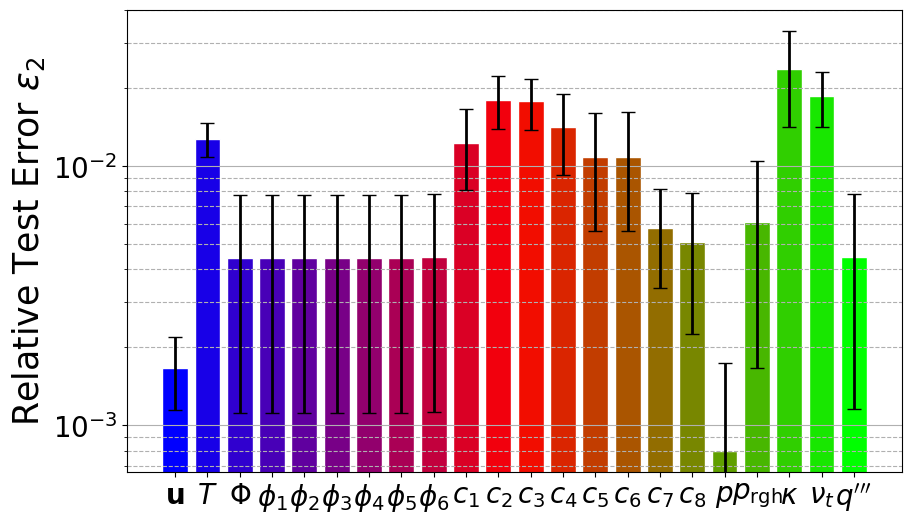

In [14]:
fig, axs = plt.subplots(nrows = 1, ncols = 1, figsize=(10,6))

colors = cm.brg(np.linspace(0,1, len(var_names)))
axs.bar(np.arange(1, len(var_names)+1, 1), ave_rel_errors['mean'].mean(axis=2).mean(axis=1), 
        yerr = ave_rel_errors['mean'].mean(axis=1).std(axis=1), capsize=5,
        # yerr = ave_rel_errors['std'].mean(axis=2).mean(axis=1), capsize=5,
        color = colors,
        edgecolor='white',error_kw={'elinewidth': 2, 'ecolor': 'black', 'capsize': 5})

axs.set_yscale('log')
axs.set_xticks(np.arange(1,len(var_names)+1,1), ['$'+tex_+'$' for tex_ in tex_var_names])
# axs.set_yticks(np.arange(0,0.1,0.01))

axs.tick_params(axis='both', labelsize=20)
axs.set_ylabel(r'Relative Test Error $\varepsilon_{2}$', fontsize=25)
axs.grid(axis='y', linestyle='-')
axs.grid(axis='y', which='minor', linestyle='--')

fig.savefig(path_test+'fom_relativerrror_bars.pdf', format='pdf', dpi=250, bbox_inches='tight')

### Lumped QoI comparison (MP vs MF-SHRED vs LF)

The 0D LF model provides scalar trajectories only. For fields with a direct LF counterpart (`T`, `prec1`–`prec8`), we compare normalized in-core averages $\overline{\varphi}(t) / \overline{\varphi}(0)$:

- **MP (OpenFOAM)** — in-core spatial average of the POD-reconstructed field;
- **MF-SHRED** — same average after decoding the predicted coefficients;
- **LF (0D DDE)** — lumped scalar from the circulating-fuel model.

This follows the comparison strategy in `01_LF_vs_HF_comparison.ipynb` and closes the fidelity loop from LF input to MP target.

In [15]:
vars_to_compare = [idx for idx in range(len(var_names)) if var_names[idx] in hf_to_lf_idx][:4]

fom_average = dict()
shred_average = dict()
shred_std = dict()
lf_average = dict()

for ii in range(len(vars_to_compare)):
    field = var_names[vars_to_compare[ii]]

    # MP (OpenFOAM FOM)
    u_data  = pickle.load(open(path_snaps + f'CompressedDataset/pod_basis_{field}.svd', 'rb'))
    s_data  = pickle.load(open(path_snaps + f'CompressedDataset/sing_vals_{field}.svd', 'rb'))
    vh_data = pickle.load(open(path_snaps + f'CompressedDataset/v_POD_all_fields.svd', 'rb'))[field]

    fom_average[field] = np.zeros((len(idx_params['test']), len(fom_times)))
    for param_to_recon in tqdm(range(len(idx_params['test'])), 'Computing averages for '+field):
        fom = rescaling_snaps[vars_to_compare[ii]].inverse_transform(
            u_data @ s_data @ vh_data[idx_params['test'][param_to_recon]].T
        )
        fom_average[field][param_to_recon] = fom[in_core_idx].mean(axis=0)

    # MF-SHRED
    idx_to_rec = np.arange(sum(Nmodes[:vars_to_compare[ii]]), sum(Nmodes[:vars_to_compare[ii]+1]), 1, dtype=int)

    u_svd = u_data[:, :Nmodes[vars_to_compare[ii]]]
    s_svd = s_data[:Nmodes[vars_to_compare[ii]], :Nmodes[vars_to_compare[ii]]]

    _tmp_mean_v = pod_scaler.inverse_transform(mf_reshaped_POD_pred_out['mean'].reshape(-1, sum(Nmodes))).reshape(mf_reshaped_POD_pred_out['mean'].shape[0], mf_reshaped_POD_pred_out['mean'].shape[1], sum(Nmodes))
    _tmp_full_v = np.array([pod_scaler.inverse_transform(mf_reshaped_POD_pred_out['full'][kk].reshape(-1, sum(Nmodes))).reshape(mf_reshaped_POD_pred_out['mean'].shape[0], mf_reshaped_POD_pred_out['mean'].shape[1], sum(Nmodes)) for kk in range(n_configurations)])

    shred_average[field] = np.zeros((len(idx_params['test']), len(fom_times)))
    shred_std[field]     = np.zeros((len(idx_params['test']), len(fom_times)))

    for pp in range(len(idx_params['test'])):
        recon = rescaling_snaps[vars_to_compare[ii]].inverse_transform(
            u_svd @ s_svd @ _tmp_mean_v[pp, :, idx_to_rec]
        )

        shred_average[field][pp] = recon[in_core_idx].mean(axis=0)

        std_recon = np.zeros((u_svd.shape[0], len(fom_times)))
        for kk in range(n_configurations):
            std_recon += (rescaling_snaps[vars_to_compare[ii]].inverse_transform(
                u_svd @ s_svd @ _tmp_full_v[kk][pp, :, idx_to_rec]
            ) - recon) ** 2 / (n_configurations - 1)
        std_recon = np.sqrt(std_recon) / np.sqrt(n_configurations)

        shred_std[field][pp] = std_recon[in_core_idx].mean(axis=0)

    # LF (0D DDE)
    lf_average[field] = np.zeros((len(idx_params['test']), len(fom_times)))
    for pp in range(len(idx_params['test'])):
        lf_average[field][pp] = lf_snaps[idx_params['test'][pp], :, hf_to_lf_idx[field]]

    del u_data, s_data, vh_data, u_svd, s_svd, recon, std_recon


Computing averages for prec3: 100%|██████████| 3/3 [00:00<00:00,  9.98it/s]


### Plot lumped QoI time histories

Normalized in-core averages ($\overline{\varphi}(t) / \overline{\varphi}(0)$) are plotted for each test $\tau^\star$ and saved to `Results/fom_shred_lf_QoIcomparison.pdf`.

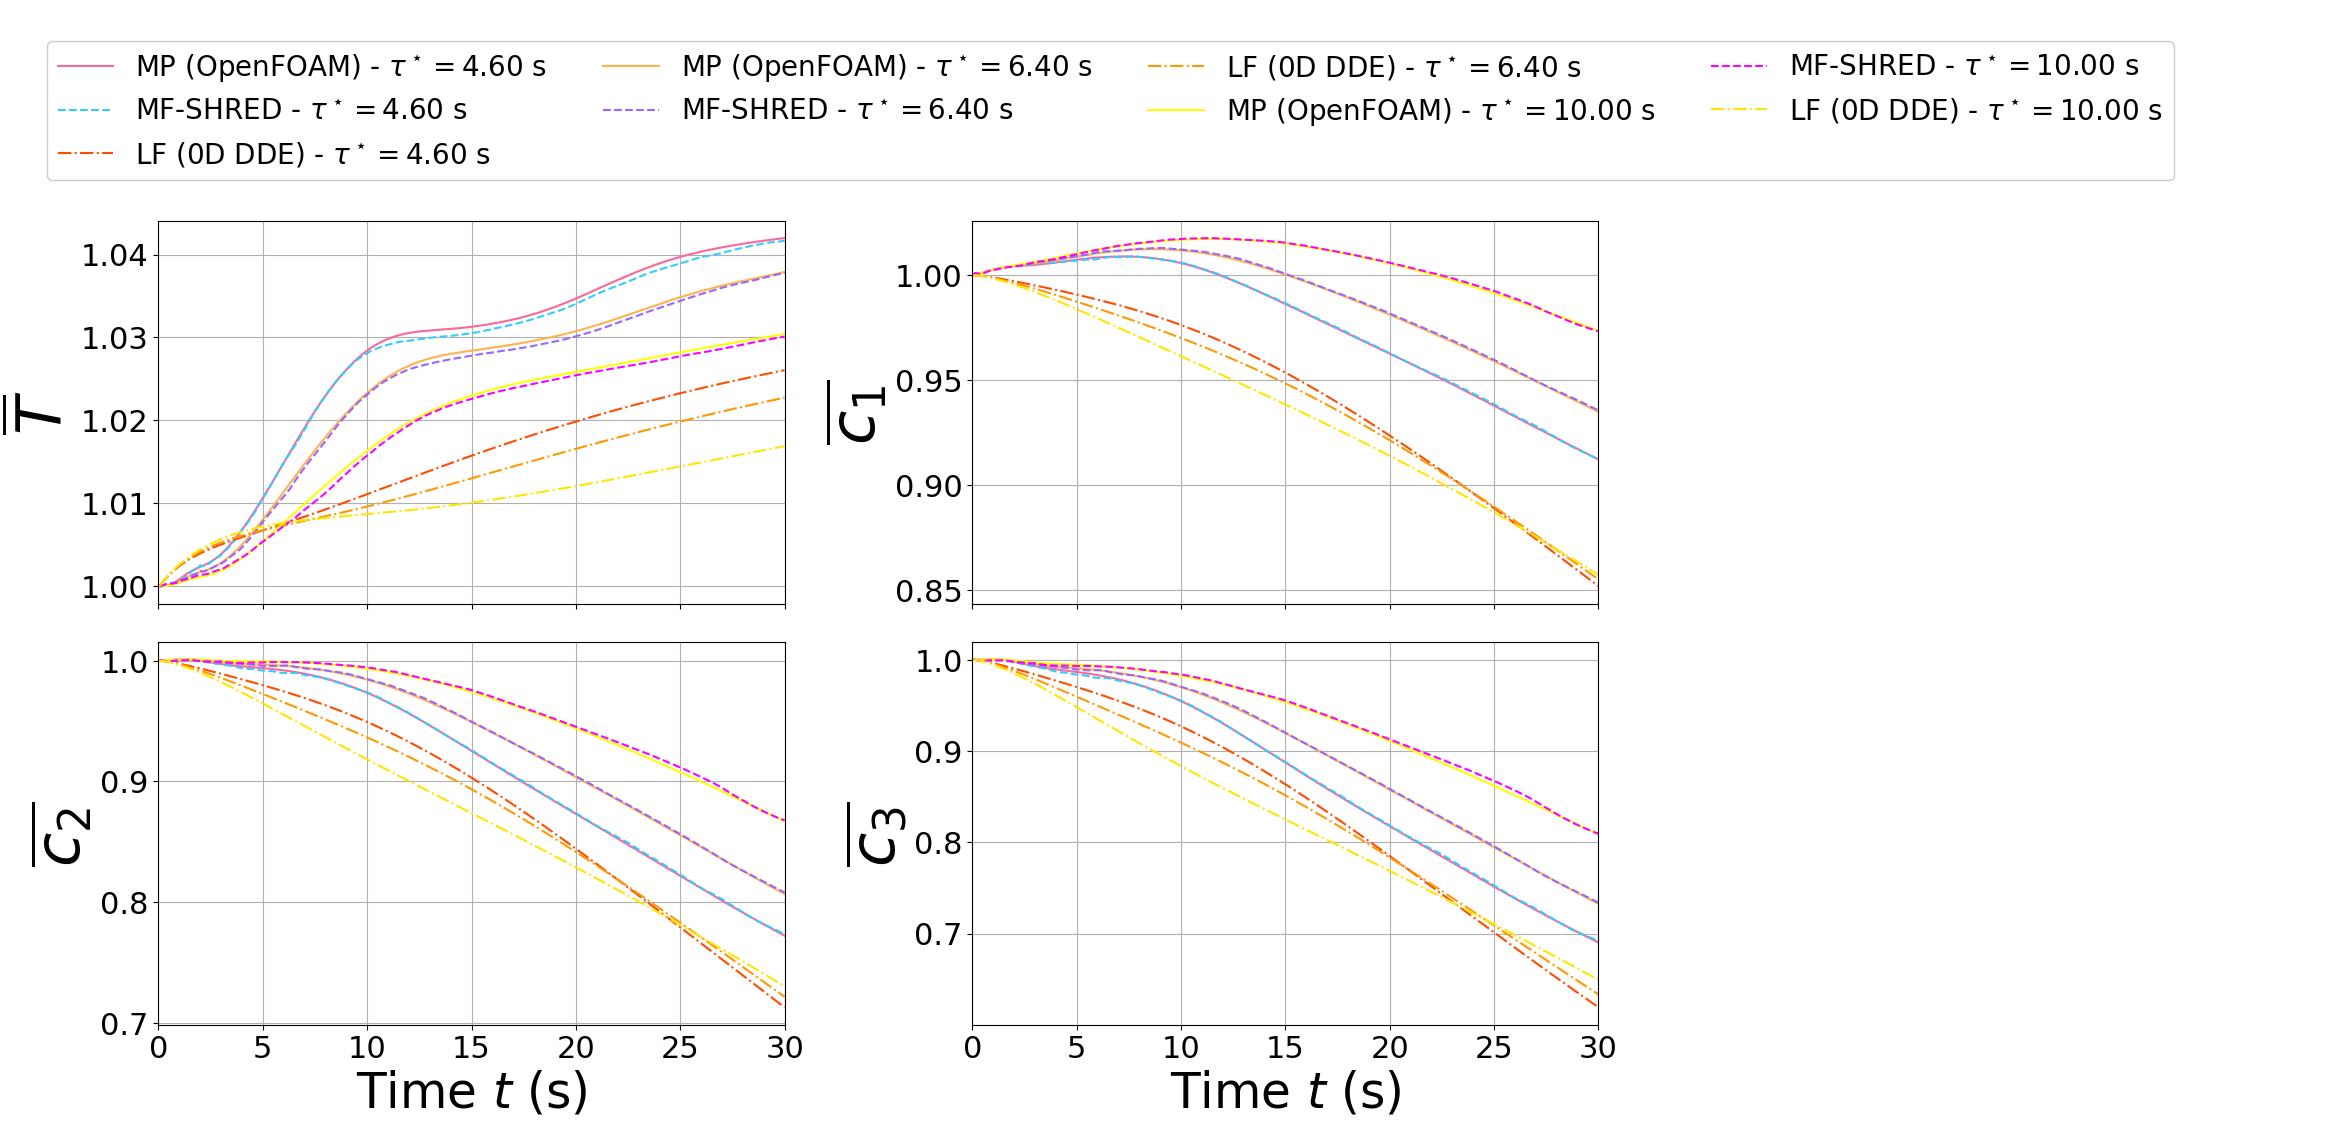

In [23]:
nrows = 2
ncols = 2
fig, axs = plt.subplots(nrows=nrows, ncols=ncols, sharex=True, figsize=(8 * ncols, 6 * nrows))
axs = axs.flatten()

colors = cm.spring(np.linspace(0.4, 1, len(idx_params['test'])))
colors_shred = cm.cool(np.linspace(0.2, 1, len(idx_params['test'])))
colors_lf = cm.autumn(np.linspace(0.3, 0.9, len(idx_params['test'])))

for ii in range(len(vars_to_compare)):
    field = var_names[vars_to_compare[ii]]

    for pp in range(len(idx_params['test'])):
        tau_label = params[idx_params['test'][pp], 0]
        axs[ii].plot(
            fom_times, fom_average[field][pp] / fom_average[field][pp, 0], '-',
            label=rf'MP (OpenFOAM) - $\tau^\star = {tau_label:.2f}$ s',
            color=colors[pp], lw=1.5,
        )
        axs[ii].plot(
            fom_times, shred_average[field][pp] / shred_average[field][pp, 0], '--',
            label=rf'MF-SHRED - $\tau^\star = {tau_label:.2f}$ s',
            color=colors_shred[pp], lw=1.5,
        )
        # axs[ii].fill_between(
        #     fom_times,
        #     y1=shred_average[field][pp] - 1.96 * shred_std[field][pp],
        #     y2=shred_average[field][pp] + 1.96 * shred_std[field][pp],
        #     color=colors_shred[pp], alpha=0.25,
        #     label=rf'95% CI - $\tau^\star = {tau_label:.2f}$ s',
        # )
        axs[ii].plot(
            fom_times, lf_average[field][pp] / lf_average[field][pp, 0], '-.',
            label=rf'LF (0D DDE) - $\tau^\star = {tau_label:.2f}$ s',
            color=colors_lf[pp], lw=1.5,
        )

    axs[ii].set_xlim(0, fom_times[-1])
    axs[ii].set_ylabel(r"$\overline{" + tex_var_names[vars_to_compare[ii]] + r"}$", fontsize=45)
    if ii >= ncols:
        axs[ii].set_xlabel(r'Time $t$ (s)', fontsize=35)

    axs[ii].grid()
    axs[ii].tick_params(axis='both', labelsize=22)
    axs[ii].set_xticks([0, 5, 10, 15, 20, 25, 30])
    axs[ii].yaxis.get_offset_text().set_fontsize(25)

for jj in range(len(vars_to_compare), nrows * ncols):
    axs[jj].set_visible(False)

Line, Label = axs[0].get_legend_handles_labels()
fig.legend(Line, Label, fontsize=20, ncols=4, framealpha=1, loc=(0.02, 0.84))
fig.subplots_adjust(left=0, wspace=0.3, top=0.78, hspace=0.1)
fig.savefig(path_test + 'fom_shred_lf_QoIcomparison.pdf', format='pdf', dpi=150, bbox_inches='tight')


### Spatial contour comparison

Full MP fields are compared against MF-SHRED reconstructions on the OpenFOAM mesh. Each frame shows three panels:

1. **MP (OpenFOAM)** — ground-truth field at time $t$;
2. **MF-SHRED** — decoded reconstruction (ensemble mean across sensor configurations);
3. **$|$MP $-$ MF-SHRED$|$** — pointwise absolute residual.

When the selected field has an LF counterpart, the annotation box also reports the LF in-core average at that time (the LF model has no spatial distribution). Contour utilities are imported from `Code/P2/plots.py`, following the style of `02_shred_outcore.ipynb`.

In [17]:
from plots import plot_contour, create_streamlines

cmaps = [
    cm.RdYlBu_r,
    sns.color_palette("icefire", as_cmap=True),
    sns.color_palette("cubehelix", as_cmap=True),
    sns.color_palette("cubehelix", as_cmap=True),
    sns.color_palette("cubehelix", as_cmap=True),
    sns.color_palette("cubehelix", as_cmap=True),
    sns.color_palette("cubehelix", as_cmap=True),
    sns.color_palette("cubehelix", as_cmap=True),
    sns.color_palette("cubehelix", as_cmap=True),
    sns.cubehelix_palette(as_cmap=True),
    sns.cubehelix_palette(as_cmap=True),
    sns.cubehelix_palette(as_cmap=True),
    sns.cubehelix_palette(as_cmap=True),
    sns.cubehelix_palette(as_cmap=True),
    sns.cubehelix_palette(as_cmap=True),
    sns.cubehelix_palette(as_cmap=True),
    sns.cubehelix_palette(as_cmap=True),
    sns.color_palette("mako", as_cmap=True),
    sns.color_palette("mako", as_cmap=True),
    sns.color_palette("Blues", as_cmap=True),
    sns.color_palette("YlOrBr", as_cmap=True),
    cm.jet,
]

nodes = pickle.load(open(path_snaps+'domain.pkl', 'rb'))

### Select field and test case

Select the field index (`field_i`), test parameter (`param_to_plot`), and reconstruct the MP reference field from the stored POD basis.


In [18]:
field_i = 1 # 0, 1, 3, 9
field = var_names[field_i]
idx_to_rec = np.arange(sum(Nmodes[:field_i]),  sum(Nmodes[:field_i+1]),  1, dtype=int)

param_to_plot = 0

u_data  = pickle.load(open(path_snaps + f'CompressedDataset/pod_basis_{field}.svd', 'rb'))
s_data  = pickle.load(open(path_snaps + f'CompressedDataset/sing_vals_{field}.svd', 'rb'))
vh_data = pickle.load(open(path_snaps + f'CompressedDataset/v_POD_all_fields.svd', 'rb'))[field]

fom = rescaling_snaps[field_i].inverse_transform(u_data @ s_data @ vh_data[idx_params['test'][param_to_plot]].T)

### Decode MF-SHRED reconstruction

Decode the MF-SHRED ensemble-mean POD coefficients and compute the per-node standard deviation across sensor configurations.


In [19]:
u_svd = u_data[:, :Nmodes[field_i]]
s_svd = s_data[:Nmodes[field_i], :Nmodes[field_i]]

_tmp_mean_v = pod_scaler.inverse_transform(mf_reshaped_POD_pred_out['mean'].reshape(-1, sum(Nmodes))).reshape(mf_reshaped_POD_pred_out['mean'].shape[0], mf_reshaped_POD_pred_out['mean'].shape[1], sum(Nmodes))
# _tmp_std_v  = vpod_scaler.inverse_transform(reshaped_POD_test_out['std'][:,:,:-1].reshape( -1, sum(Nmodes))).reshape(reshaped_POD_test_out['std'][:,:,:-1].shape) - vpod_scaler.data_min_
_tmp_full_v = np.array([pod_scaler.inverse_transform(mf_reshaped_POD_pred_out['full'][kk].reshape(-1, sum(Nmodes))).reshape(mf_reshaped_POD_pred_out['mean'].shape[0], mf_reshaped_POD_pred_out['mean'].shape[1], sum(Nmodes)) for kk in range(n_configurations)])

recon = rescaling_snaps[field_i].inverse_transform(
    u_svd @ s_svd @ _tmp_mean_v[param_to_plot, :, idx_to_rec]
)

std_recon = np.zeros((u_svd.shape[0], len(fom_times)))
for kk in range(n_configurations):
    std_recon +=  (rescaling_snaps[field_i].inverse_transform(u_svd @ s_svd @ _tmp_full_v[kk][param_to_plot, :, idx_to_rec]) - recon) ** 2 / (n_configurations - 1)
std_recon = np.sqrt(std_recon) / np.sqrt(n_configurations)

### Generate contour frames

Snapshots are written to `Results/Figs/Param_<τ>/<field>/` at selected time steps and assembled into a GIF for the paper figures.

In [25]:
import matplotlib.ticker as mticker
        
path_fig = path_test+'Figs/Param_{:.2f}'.format(params[idx_params['test'][param_to_plot],0])+'/'+field+'/'
os.makedirs(path_fig, exist_ok=True)

vec_mode_to_plot = 'Mag' if field_i == 0 else None
streamline_plot = True if field_i == 0 else False

# Add titles
if vec_mode_to_plot is not None:
    _var = r'$\|'+tex_var_names[field_i]+'\|_2$'
else:
    _var = r'$'+tex_var_names[field_i]+'$'

ncols = 3

resid = np.abs(fom - recon)

for time_to_plot in tqdm(np.arange(19, len(fom_times), 20)):

    vec_mode_to_plot = 'Mag' if field_i == 0 else None
    streamline_plot = True if field_i == 0 else False

    if vec_mode_to_plot is not None:
        _var = r'$\|'+tex_var_names[field_i]+'\|_2$'
    else:
        _var = r'$'+tex_var_names[field_i]+'$'

    fig, axs = plt.subplots(nrows=1, ncols=ncols, figsize=(4 * ncols, 4), dpi=250)
    levels = np.linspace(0,1.5,100) if vec_mode_to_plot is not None else np.linspace(fom.min(), fom.max(), 200)

    fom_contour = plot_contour(axs[0], nodes, fom[:, time_to_plot], cmap=cmaps[field_i],
                               streamline_plot=streamline_plot,
                               vec_mode_to_plot=vec_mode_to_plot, levels=levels)

    recon_contour = plot_contour(axs[1], nodes, recon[:, time_to_plot], cmap=cmaps[field_i],
                                 streamline_plot=streamline_plot,
                                 vec_mode_to_plot=vec_mode_to_plot, levels=levels)

    resid_contour = plot_contour(axs[2], nodes, resid[:, time_to_plot],
                                 vec_mode_to_plot=vec_mode_to_plot, cmap=cm.hot, levels=30)
    cbar_res = fig.colorbar(resid_contour,
                            ax=axs[2], orientation='vertical', pad=0.05, aspect=20, shrink=0.75)
    cbar_res.ax.tick_params(labelsize=12)
    cbar_res.ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    axs[2].set_title(r'$|$MP $-$ MF-SHRED$|$ - '+_var, fontsize=20)

    fig.subplots_adjust(wspace=0.05)

    cbar_fom = fig.colorbar(fom_contour,
                            ax=axs[:2], orientation='horizontal', pad=0.05, aspect=20, shrink=0.85)
    cbar_fom.ax.tick_params(labelsize=10)

    axs[0].set_title(r'MP (OpenFOAM) - '+_var, fontsize=20)
    axs[1].set_title(r'MF-SHRED - '+_var, fontsize=20)

    _annot = (
        r'Time $t={:.2f}$'.format(fom_times[time_to_plot]) + r' s'
        + r' - Parameter $\tau = {:.2f}$ s'.format(params[idx_params['test'][param_to_plot], 0])
    )
    if field in hf_to_lf_idx:
        _lf_val = lf_snaps[idx_params['test'][param_to_plot], time_to_plot, hf_to_lf_idx[field]]

    axs[-1].annotate(
        _annot,
        xy=(-0.15, -0.1), xycoords='axes fraction', fontsize=12, color='black',
        bbox=dict(boxstyle="round,pad=0.3", edgecolor='black', facecolor='yellow', lw=2),
    )

    fig.savefig(path_fig+'FOM_vs_SHRED_{:.2f}'.format(fom_times[time_to_plot])+'.png',
                format='png', dpi=250, bbox_inches='tight', transparent=False)
    plt.close(fig)

100%|██████████| 30/30 [00:34<00:00,  1.14s/it]


### Assemble GIF

PNG frames are stitched into an animated GIF and copied to `Code/media/P2/` for inclusion in the repository README.

In [ ]:
import imageio.v2 as imageio

# Create the GIF by loading each image and adding it to the array
def get_gif(gif_path, image_files, duration=150.):
    with imageio.get_writer(gif_path, mode='I', duration=duration, loop=0) as writer:
        for img_file in image_files:
            img_path = os.path.join(path_fig, img_file)
            image = imageio.imread(img_path)
            writer.append_data(image)

# Create the MP4 video by loading each image and adding it to the array
def get_video(video_path, image_files, fps=10):
    with imageio.get_writer(video_path, fps=fps, codec="libx264") as writer:
        for img_file in image_files:
            img_path = os.path.join(path_fig, img_file)
            image = imageio.imread(img_path)
            writer.append_data(image)

image_files = sorted(os.listdir(path_fig), key=lambda x: int(x.split('_')[-1].split('.')[0]))

get_gif(path_test+'Figs/Param_{:.2f}/'.format(params[idx_params['test'][param_to_plot],0])+var_names[field_i]+'.gif', image_files, duration=200.)
# get_video(path_test+'Figs/Param_{:.2f}/'.format(params[idx_params['test'][param_to_plot],0])+var_names[field_i]+'.mp4', image_files, fps=5)

os.makedirs('../../media/P2/', exist_ok=True)
os.system('mv '+path_test+'Figs/Param_{:.2f}/'.format(params[idx_params['test'][param_to_plot],0])+var_names[field_i]+'.gif ../../media/P2/'+var_names[field_i]+'.gif')

### Ensemble uncertainty at final time

A three-panel snapshot at $t = t_{\mathrm{end}}$ shows the MP field, the MF-SHRED reconstruction, and the cross-configuration standard deviation — highlighting where sensor-placement variability matters most.

In [27]:
time_to_plot = len(fom_times) - 1
    
vec_mode_to_plot = 'Mag' if field_i == 0 else None
streamline_plot = True if field_i == 0 else False

fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(12, 4), dpi=250)
levels = np.linspace(0,0.4,100) if vec_mode_to_plot is not None else np.linspace(fom[:, time_to_plot].min(), fom[:, time_to_plot].max()*1.01, 200)

# FOM plot
fom_contour = plot_contour(axs[0], nodes, fom[:, time_to_plot], cmap=cmaps[field_i],
                            streamline_plot = streamline_plot,
                            vec_mode_to_plot=vec_mode_to_plot, levels=levels)

# Reconstruction plot
recon_contour = plot_contour(axs[1], nodes, recon[:, time_to_plot], cmap=cmaps[field_i],
                            streamline_plot = streamline_plot,
                            vec_mode_to_plot=vec_mode_to_plot, levels=levels)

# # Residual plot
# resid_contour = plot_contour(axs[2], domain_plot, np.abs(fom - recon)[:, time_to_plot],
#                             vec_mode_to_plot=vec_mode_to_plot, cmap=cm.hot, levels=20)

# Std-Deviation plot
resid_contour = plot_contour(axs[2], nodes, std_recon[:, time_to_plot],
                            streamline_plot = streamline_plot,
                            vec_mode_to_plot=vec_mode_to_plot, cmap=cm.hot, levels=200)

fig.subplots_adjust(wspace=0.05)

# Add colorbars
cbar_fom = fig.colorbar(fom_contour, 
                        ax=axs[:2], orientation='horizontal', pad=0.05, aspect=40, shrink = 0.85)
cbar_fom.ax.tick_params(labelsize=12)
# cbar_fom.ax.set_xticks([0,0.1, 0.2, 0.3, 0.4]) # U
# cbar_fom.ax.set_xticks(np.arange(900, 1301, 50)) # T

cbar_res = fig.colorbar(resid_contour,
                        ax=axs[2], orientation='vertical', pad=0.05, aspect=20, shrink = 0.75)
cbar_res.ax.tick_params(labelsize=12)

# Add titles
if vec_mode_to_plot is not None:
    _var = r'$\|'+tex_var_names[field_i]+'\|_2$'
else:
    _var = r'$'+tex_var_names[field_i]+'$'

axs[0].set_title(r'MP (OpenFOAM) - '+_var, fontsize=20)
axs[1].set_title(r'MF-SHRED - '+_var, fontsize=20)
axs[2].set_title(r'Standard Dev - '+_var, fontsize=20)

_annot = (
    r'Time $t={:.2f}$'.format(fom_times[time_to_plot]) + r' s'
    + r' - Parameter $\tau = {:.2f}$ s'.format(params[idx_params['test'][param_to_plot], 0])
)
if field in hf_to_lf_idx:
    _lf_val = lf_snaps[idx_params['test'][param_to_plot], time_to_plot, hf_to_lf_idx[field]]
    # _annot += r' - LF $\overline{' + tex_var_names[field_i] + r'} = {:.2f}$'.format(_lf_val)

axs[2].annotate(
    _annot,
    xy=(-0.15, -0.1), xycoords='axes fraction', fontsize=12,
    bbox=dict(boxstyle="round,pad=0.3", edgecolor='black', facecolor='yellow', lw=2),
)

fig.subplots_adjust(wspace=0., bottom = 0.25)

fig.savefig(path_test+field+'_FOM_vs_SHRED_{:.2f}'.format(fom_times[time_to_plot])+'.png', 
            format='png', dpi=250, bbox_inches='tight')
plt.close(fig)